In [30]:
import csv
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pmdarima as pm
import json

from pmdarima import auto_arima
from statsmodels.tsa.api import SimpleExpSmoothing, Holt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [31]:
#with open('/Users/yimengliu/Documents/Erdos_Institute/mgp/summer26-math-genealogy/data/processed/data-new.json',"r") as file:
#    tree=json.load(file)
#nodes = pd.DataFrame(tree['nodes'])

In [32]:
#renaming the feature name to adapt previous codes.
#nodes = nodes.rename(columns={'subject': 'subject_code'})

In [33]:
nodes = pd.read_csv(
    "/Users/yimengliu/Documents/Erdos_Institute/mgp/summer26-math-genealogy/data/processed/version2_new_dataset_fitted.csv"
)

In [34]:
nodes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338532 entries, 0 to 338531
Data columns (total 13 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   id                             338532 non-null  int64  
 1   name                           338526 non-null  object 
 2   thesis                         307399 non-null  object 
 3   school                         276167 non-null  object 
 4   country                        322986 non-null  object 
 5   year                           277237 non-null  float64
 6   advisors                       338532 non-null  object 
 7   students                       338532 non-null  object 
 8   subject_code                   280203 non-null  float64
 9   subject_name                   280203 non-null  object 
 10  predicted_subject_code         130825 non-null  float64
 11  subject_prediction_confidence  136040 non-null  float64
 12  subject_prediction_vector     

In [35]:
nodes=nodes[(~nodes['subject_code'].isna())&(nodes['predicted_subject_code'].isna())]

In [36]:
nodes= nodes.drop('predicted_subject_code', axis=1)

In [37]:
nodes= nodes.drop(columns=['subject_prediction_confidence'])

In [38]:
nodes= nodes.drop(columns=['subject_prediction_vector'])

In [39]:
nodes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 202492 entries, 0 to 338531
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            202492 non-null  int64  
 1   name          202492 non-null  object 
 2   thesis        193399 non-null  object 
 3   school        166999 non-null  object 
 4   country       200557 non-null  object 
 5   year          167749 non-null  float64
 6   advisors      202492 non-null  object 
 7   students      202492 non-null  object 
 8   subject_code  202492 non-null  float64
 9   subject_name  202492 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 17.0+ MB


## 0. Data preparation

The matrices use subject codes as row labels, but `.iloc` selects by row position.  
For example, subject code 14 is currently at row position 9.

In [40]:
# Use annual data from 1960 through 2024.
years = np.arange(1960, 2025)

valid_pure = nodes[
    nodes["subject_code"].notna()
    & (nodes["subject_code"] < 61)
    & nodes["year"].between(1960, 2024)
].copy()

valid_pure["year"] = valid_pure["year"].astype(int)

codes_pure = np.sort(valid_pure["subject_code"].unique())

counts = (
    pd.crosstab(valid_pure["subject_code"], valid_pure["year"])
    .reindex(index=codes_pure, columns=years, fill_value=0)
)

# Total number of pure-math graduates in each year.
year_totals = counts.sum(axis=0).replace(0, np.nan)

# Subject share within the pure-math basket, stored in percentage points.
share = counts.div(year_totals, axis=1) * 100

print("counts shape:", counts.shape)
print("share shape:", share.shape)
print("Years with undefined shares:", share.columns[share.isna().any()].tolist())
print("Share-column sums:", share.sum(axis=0).round(6).unique())


counts shape: (44, 65)
share shape: (44, 65)
Years with undefined shares: []
Share-column sums: [100.]


In [41]:
# Select subject code 14 by first finding its row position.
subject_code = 14

matching_positions = np.flatnonzero(
    counts.index.to_numpy() == subject_code
)

if len(matching_positions) == 0:
    raise KeyError(f"Subject code {subject_code} is not present in counts.")

subject_row_position = int(matching_positions[0])

counts_subject14 = counts.iloc[subject_row_position].astype(float)
share_subject14 = share.iloc[subject_row_position].astype(float)
year_values = counts.columns.to_numpy(dtype=int)

print("Subject code:", subject_code)
print("Row position:", subject_row_position)
print("Row label at that position:", counts.index[subject_row_position])

Subject code: 14
Row position: 9
Row label at that position: 14.0


## 1. Forecasting models

In [42]:
def forecast_models(train, train_years, forecast_years):
    """Fit all candidate models using one training fold."""

    train = np.asarray(train, dtype=float)
    train_years = np.asarray(train_years, dtype=float)
    forecast_years = np.asarray(forecast_years, dtype=float)
    horizon = len(forecast_years)

    forecasts = {}

    # 1. SES with fixed alpha = 0.5.
    ses_fixed = SimpleExpSmoothing(
        train,
        initialization_method="estimated"
    ).fit(
        smoothing_level=0.5,
        optimized=False
    )
    forecasts["SES fixed alpha=0.5"] = np.asarray(
        ses_fixed.forecast(horizon),
        dtype=float
    )

    # 2. SES with alpha estimated inside the current training fold.
    ses_optimized = SimpleExpSmoothing(
        train,
        initialization_method="estimated"
    ).fit(
        optimized=True
    )
    forecasts["SES optimized"] = np.asarray(
        ses_optimized.forecast(horizon),
        dtype=float
    )

    # 3. Ordinary Holt model, with parameters estimated inside the fold.
    holt_optimized = Holt(
        train,
        damped_trend=False,
        initialization_method="estimated"
    ).fit(optimized=True)
    forecasts["Holt optimized"] = np.asarray(
        holt_optimized.forecast(horizon),
        dtype=float
    )

    # 4. Damped Holt model, with parameters estimated inside the fold.
    holt_damped = Holt(
        train,
        damped_trend=True,
        initialization_method="estimated"
    ).fit(optimized=True)
    forecasts["Holt damped"] = np.asarray(
        holt_damped.forecast(horizon),
        dtype=float
    )

    # 5. Linear trend fitted only on the years in this training fold.
    linear_model = LinearRegression()
    linear_model.fit(train_years.reshape(-1, 1), train)
    forecasts["Linear trend"] = linear_model.predict(
        forecast_years.reshape(-1, 1)
    )

    # 6. Fixed ARIMA(0, 1, 1), retained as an existing benchmark.
    arima_011_model = pm.ARIMA(
        order=(0, 1, 1),
        with_intercept=False,
        suppress_warnings=True
    ).fit(train)
    forecasts["ARIMA(0,1,1)"] = np.asarray(
        arima_011_model.predict(n_periods=horizon),
        dtype=float
    )

    # 7. Auto-ARIMA.
    auto_model = auto_arima(
        train,
        start_p=0,
        start_q=0,
        max_p=3,
        max_q=3,
        seasonal=False,
        stepwise=True,
        suppress_warnings=True,
        error_action="ignore",
        trace=False
    )
    forecasts["Auto ARIMA"] = np.asarray(
        auto_model.predict(n_periods=horizon),
        dtype=float
    )

    return forecasts


## 2. Rolling-window cross-validation

In [43]:
def rolling_window_cv(
    y,
    year_values,
    window_size=20,
    horizon=3,
    step=3
):
    """Run fixed-length rolling-window time-series cross-validation.

    Returns
    -------
    metrics : pandas.DataFrame
        One row per fold and model.
    forecast_details : pandas.DataFrame
        One row per forecasted year and model.
    """

    y = np.asarray(y, dtype=float)
    year_values = np.asarray(year_values)

    if len(y) != len(year_values):
        raise ValueError("y and year_values must have the same length.")

    if window_size < 2:
        raise ValueError("window_size must be at least 2.")

    if horizon < 1 or step < 1:
        raise ValueError("horizon and step must be positive.")

    if window_size + horizon > len(y):
        raise ValueError(
            "window_size + horizon cannot exceed the series length."
        )

    if np.isnan(y).any():
        missing_years = year_values[np.isnan(y)]
        raise ValueError(
            f"The series contains missing values in years "
            f"{missing_years.tolist()}."
        )

    metric_records = []
    forecast_records = []
    fold_number = 0

    for test_start in range(
        window_size,
        len(y) - horizon + 1,
        step
    ):
        fold_number += 1

        train_start = test_start - window_size
        test_end = test_start + horizon

        train = y[train_start:test_start]
        test = y[test_start:test_end]

        train_years = year_values[train_start:test_start]
        test_years = year_values[test_start:test_end]

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            forecasts = forecast_models(
                train=train,
                train_years=train_years,
                forecast_years=test_years
            )

        mase_scale = np.mean(np.abs(np.diff(train)))

        for model_name, prediction in forecasts.items():
            prediction = np.asarray(prediction, dtype=float)

            if len(prediction) != len(test):
                raise ValueError(
                    f"{model_name} returned {len(prediction)} predictions "
                    f"for a test set of length {len(test)}."
                )

            fold_mse = mean_squared_error(test, prediction)
            fold_mae = mean_absolute_error(test, prediction)

            metric_records.append({
                "fold": fold_number,
                "model": model_name,
                "train_start": int(train_years[0]),
                "train_end": int(train_years[-1]),
                "test_start": int(test_years[0]),
                "test_end": int(test_years[-1]),
                "MSE": fold_mse,
                "RMSE": np.sqrt(fold_mse),
                "MAE": fold_mae,
                "MASE": (
                    fold_mae / mase_scale
                    if mase_scale > 0
                    else np.nan
                )
            })

            for year, actual, predicted in zip(
                test_years,
                test,
                prediction
            ):
                forecast_records.append({
                    "fold": fold_number,
                    "model": model_name,
                    "year": int(year),
                    "actual": float(actual),
                    "predicted": float(predicted),
                    "error": float(actual - predicted)
                })

    metrics = pd.DataFrame(metric_records)
    forecast_details = pd.DataFrame(forecast_records)

    return metrics, forecast_details

In [44]:
def summarize_cv_results(cv_metrics):
    """Average the error measures across validation folds."""

    if cv_metrics.empty:
        return pd.DataFrame()

    return (
        cv_metrics
        .groupby("model")
        .agg(
            mean_MSE=("MSE", "mean"),
            std_MSE=("MSE", "std"),
            mean_RMSE=("RMSE", "mean"),
            mean_MAE=("MAE", "mean"),
            mean_MASE=("MASE", "mean"),
            number_of_folds=("fold", "nunique")
        )
        .sort_values("mean_MSE")
    )

## 3. Subject 14: three-year rolling forecasts

With `window_size=20`, `horizon=3`, and `step=3`, every fold trains on exactly 20 years and predicts the next 3 years.

In [45]:
counts_rolling_metrics, counts_rolling_forecasts = rolling_window_cv(
    y=counts_subject14.to_numpy(),
    year_values=year_values,
    window_size=20,
    horizon=3,
    step=3
)

counts_rolling_summary = summarize_cv_results(
    counts_rolling_metrics
)
counts_rolling_summary

,mean_MSE,std_MSE,mean_RMSE,mean_MAE,mean_MASE,number_of_folds
model,,,,,,
Holt damped,251.550361,306.139578,12.854233,11.409804,1.559658,15
Holt optimized,290.178002,359.238212,13.522012,12.103281,1.587511,15
SES fixed alpha=0.5,307.492468,402.992267,14.479589,12.948279,1.877961,15
SES optimized,314.677528,408.693702,14.684966,13.130215,1.874522,15
Auto ARIMA,327.734628,479.234708,14.264787,12.951156,1.702090,15
"ARIMA(0,1,1)",328.868780,424.981268,14.957481,13.443824,1.893292,15
Linear trend,422.080488,611.196039,15.776725,14.436341,1.851054,15


In [46]:
share_rolling_metrics, share_rolling_forecasts = rolling_window_cv(
    y=share_subject14.to_numpy(),
    year_values=year_values,
    window_size=20,
    horizon=3,
    step=3
)

share_rolling_summary = summarize_cv_results(
    share_rolling_metrics
)
share_rolling_summary

,mean_MSE,std_MSE,mean_RMSE,mean_MAE,mean_MASE,number_of_folds
model,,,,,,
Linear trend,0.679495,0.909284,0.720845,0.609812,0.684986,15
Holt optimized,0.679496,0.909284,0.720846,0.609812,0.684986,15
Holt damped,0.706895,1.036681,0.728582,0.617880,0.694024,15
SES fixed alpha=0.5,0.956946,1.501425,0.837015,0.717447,0.803512,15
"ARIMA(0,1,1)",0.976601,1.323351,0.881810,0.764555,0.860779,15
SES optimized,1.110507,1.604135,0.933456,0.818515,0.917063,15
Auto ARIMA,1.231024,1.659065,0.964498,0.833842,0.895978,15


### 3.1 Error by rolling fold

In [47]:
share_rolling_metrics.pivot(
    index="fold",
    columns="model",
    values="MSE"
)

model,"ARIMA(0,1,1)",Auto ARIMA,Holt damped,Holt optimized,Linear trend,SES fixed alpha=0.5,SES optimized
fold,,,,,,,
1,0.536240,0.536251,0.635509,0.407128,0.407128,0.501067,0.536251
2,5.615834,6.791065,4.320917,3.782322,3.782321,6.219436,6.791065
3,0.660480,1.885574,0.293693,0.288229,0.288229,0.428887,0.781057
4,0.645281,0.992789,0.109869,0.102954,0.102953,0.558018,0.716205
5,0.416645,0.378994,0.509915,0.536691,0.536686,0.338244,0.453315
6,0.789080,1.747257,0.524932,0.558773,0.558773,0.877548,0.798306
7,0.424871,0.667008,0.371978,0.418402,0.418402,0.402233,0.434040
8,0.635088,1.626089,0.591751,1.019878,1.019878,0.863513,0.608903
9,0.420627,0.496588,0.159057,0.160940,0.160939,0.154808,0.766872


### 3.2 Plot rolling forecasts

In [48]:
def plot_cv_forecasts(
    original_series,
    year_values,
    cv_forecasts,
    model_name,
    title
):
    plt.figure(figsize=(16, 7))

    plt.plot(
        year_values,
        original_series,
        label="Actual series",
        linewidth=2
    )

    selected = cv_forecasts[
        cv_forecasts["model"] == model_name
    ]

    for fold in selected["fold"].unique():
        fold_data = selected[selected["fold"] == fold]

        plt.plot(
            fold_data["year"],
            fold_data["predicted"],
            marker="o",
            linestyle="--",
            alpha=0.8
        )

    plt.xlabel("Year")
    plt.ylabel("Value")
    plt.title(title)
    plt.legend()
    plt.show()

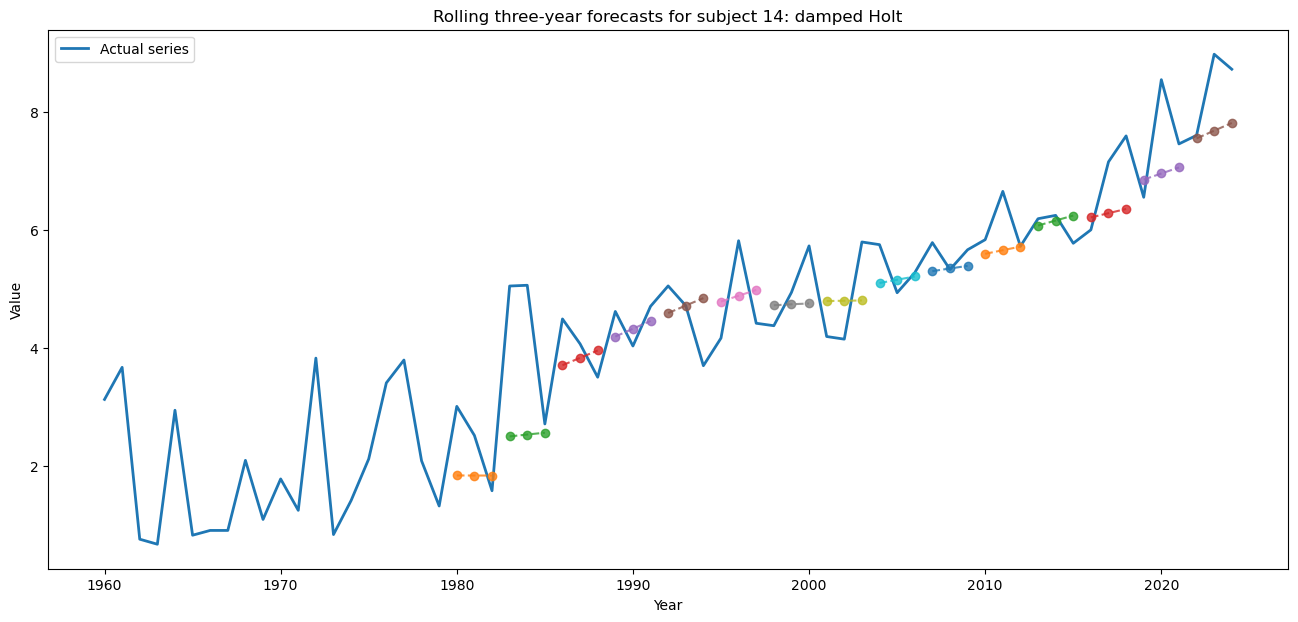

In [49]:
plot_cv_forecasts(
    original_series=share_subject14.to_numpy(),
    year_values=year_values,
    cv_forecasts=share_rolling_forecasts,
    model_name="Holt damped",
    title=(
        "Rolling three-year forecasts for subject 14: "
        "damped Holt"
    )
)

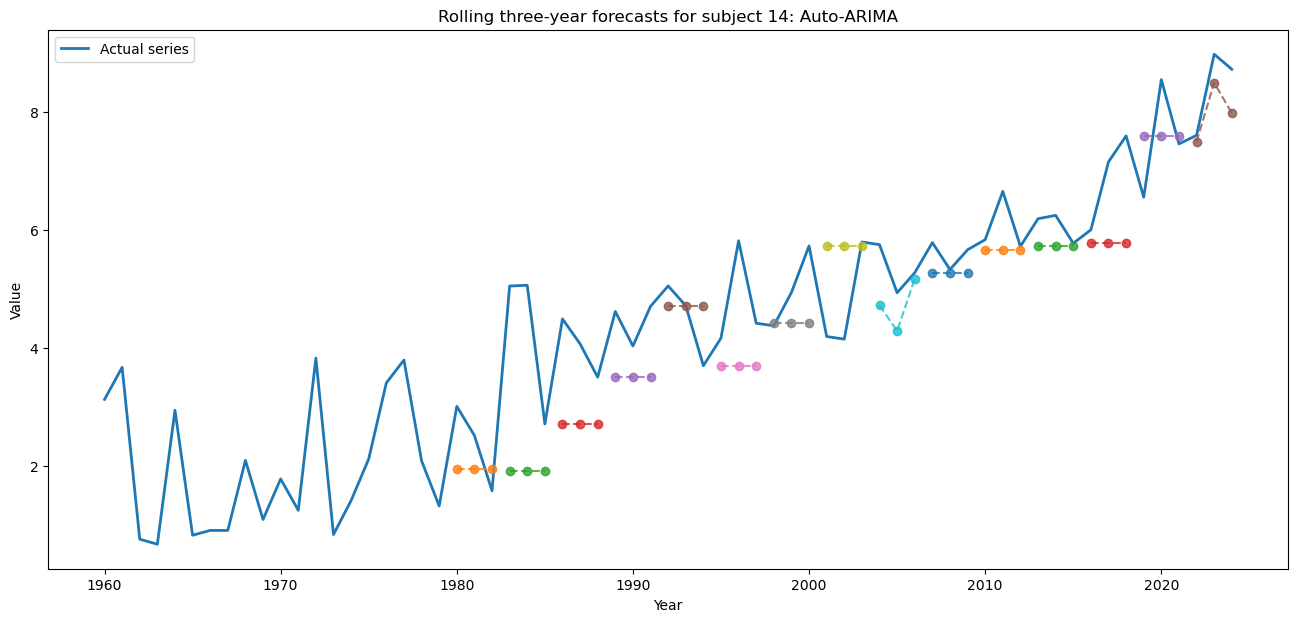

In [50]:
plot_cv_forecasts(
    original_series=share_subject14.to_numpy(),
    year_values=year_values,
    cv_forecasts=share_rolling_forecasts,
    model_name="Auto ARIMA",
    title=(
        "Rolling three-year forecasts for subject 14: "
        "Auto-ARIMA"
    )
)

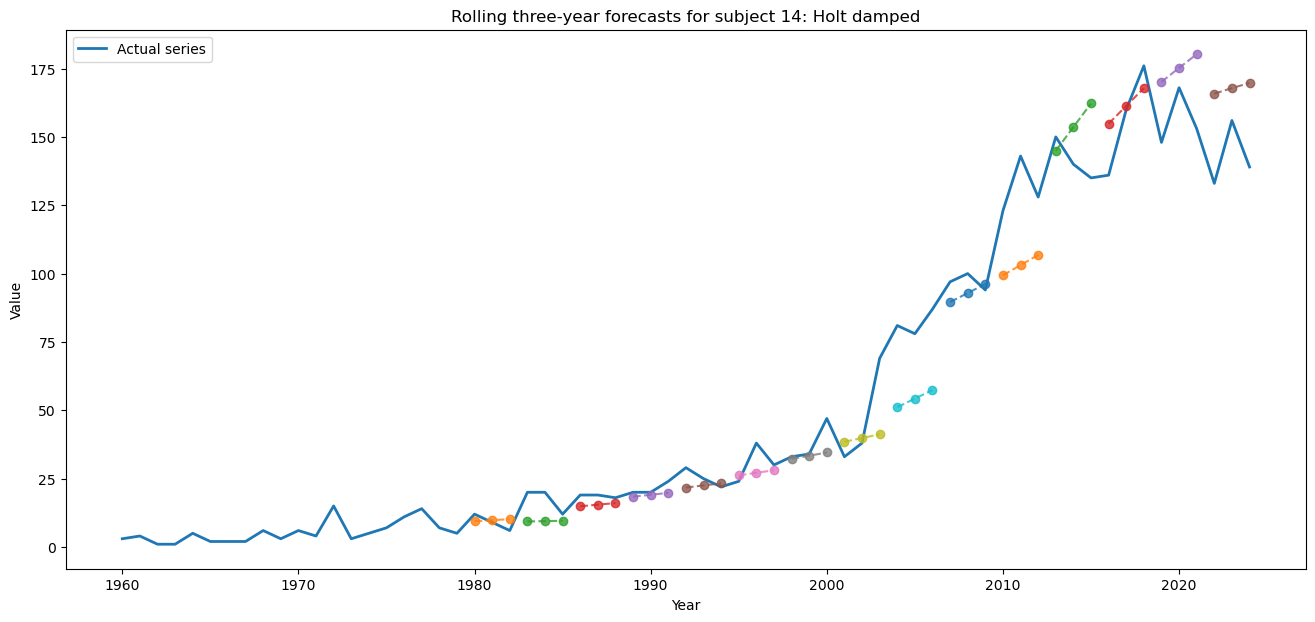

In [51]:
plot_cv_forecasts(
    original_series=counts_subject14.to_numpy(),
    year_values=year_values,
    cv_forecasts=counts_rolling_forecasts,
    model_name="Holt damped",
    title=(
        "Rolling three-year forecasts for subject 14: "
        "Holt damped"
    )
)

## 4. Alternative forecast horizons for subject 14

The training window remains 20 years so that the effect of changing the forecast horizon is not confounded with a different training-window length.

In [52]:
share_cv_1year, share_forecasts_1year = rolling_window_cv(
    y=share_subject14.to_numpy(),
    year_values=year_values,
    window_size=20,
    horizon=1,
    step=1
)

share_summary_1year = summarize_cv_results(
    share_cv_1year
)
share_summary_1year

,mean_MSE,std_MSE,mean_RMSE,mean_MAE,mean_MASE,number_of_folds
model,,,,,,
Holt damped,0.696889,1.189441,0.624937,0.624937,0.707683,45
Holt optimized,0.705060,1.094300,0.647999,0.647999,0.728497,45
Linear trend,0.711682,1.091186,0.655937,0.655937,0.740228,45
SES fixed alpha=0.5,0.836019,1.488496,0.694422,0.694422,0.796761,45
"ARIMA(0,1,1)",0.884546,1.509444,0.719978,0.719978,0.823762,45
SES optimized,0.963162,1.758346,0.740326,0.740326,0.843812,45
Auto ARIMA,1.057598,1.757610,0.811296,0.811296,0.926331,45


In [53]:
share_cv_5year, share_forecasts_5year = rolling_window_cv(
    y=share_subject14.to_numpy(),
    year_values=year_values,
    window_size=20,
    horizon=5,
    step=5
)

share_summary_5year = summarize_cv_results(
    share_cv_5year
)
share_summary_5year

,mean_MSE,std_MSE,mean_RMSE,mean_MAE,mean_MASE,number_of_folds
model,,,,,,
Linear trend,0.848700,1.048762,0.810452,0.684148,0.777914,9
Holt optimized,0.848701,1.048762,0.810452,0.684148,0.777914,9
Holt damped,0.994994,1.398846,0.858508,0.728222,0.825092,9
SES fixed alpha=0.5,1.129328,1.300666,0.938132,0.792505,0.925764,9
"ARIMA(0,1,1)",1.205704,1.330551,0.983965,0.836123,0.983641,9
SES optimized,1.244531,1.322789,1.008159,0.857648,1.009353,9
Auto ARIMA,1.437719,1.449637,1.066414,0.923245,1.063685,9


## 5. Rolling cross-validation for all subjects

In [54]:
def cross_validate_all_subjects(
    matrix,
    window_size=20,
    horizon=3,
    step=3
):
    """Run rolling-window CV on every row of a subject matrix."""

    all_results = []
    failed_subjects = []

    matrix_years = matrix.columns.to_numpy(dtype=int)

    for row_position in range(matrix.shape[0]):
        subject_code = matrix.index[row_position]
        y = matrix.iloc[row_position].astype(float)

        print(
            f"Processing row {row_position}, "
            f"subject code {subject_code}"
        )

        try:
            metrics, _ = rolling_window_cv(
                y=y.to_numpy(),
                year_values=matrix_years,
                window_size=window_size,
                horizon=horizon,
                step=step
            )

            metrics["row_position"] = row_position
            metrics["subject_code"] = subject_code
            all_results.append(metrics)

        except Exception as error:
            failed_subjects.append({
                "row_position": row_position,
                "subject_code": subject_code,
                "error": str(error)
            })
            print(
                f"Subject code {subject_code} failed: {error}"
            )

    if all_results:
        results = pd.concat(
            all_results,
            ignore_index=True
        )
    else:
        results = pd.DataFrame()

    failures = pd.DataFrame(failed_subjects)

    return results, failures

In [55]:
def summarize_models_by_subject(all_cv_results):
    """Summarize each model separately for every subject."""

    if all_cv_results.empty:
        return pd.DataFrame()

    return (
        all_cv_results
        .groupby(
            ["row_position", "subject_code", "model"]
        )
        .agg(
            mean_MSE=("MSE", "mean"),
            mean_RMSE=("RMSE", "mean"),
            mean_MAE=("MAE", "mean"),
            mean_MASE=("MASE", "mean"),
            number_of_folds=("fold", "nunique")
        )
        .reset_index()
    )


def select_best_model_by_subject(subject_model_summary):
    """Choose the lowest-mean-MSE model for each subject."""

    if subject_model_summary.empty:
        return pd.DataFrame()

    return (
        subject_model_summary
        .sort_values(
            ["subject_code", "mean_MSE"]
        )
        .groupby("subject_code", as_index=False)
        .first()
    )

### 5.1 Percentage series for all subjects

In [56]:
all_share_cv_results, share_cv_failures = cross_validate_all_subjects(
    matrix=share,
    window_size=20,
    horizon=3,
    step=3
)

print("Failed share series:", len(share_cv_failures))
share_cv_failures.head()

Processing row 0, subject code 0.0
Processing row 1, subject code 1.0
Processing row 2, subject code 3.0
Processing row 3, subject code 5.0
Processing row 4, subject code 6.0
Processing row 5, subject code 8.0
Processing row 6, subject code 11.0
Processing row 7, subject code 12.0
Processing row 8, subject code 13.0
Processing row 9, subject code 14.0
Processing row 10, subject code 15.0
Processing row 11, subject code 16.0
Processing row 12, subject code 17.0
Processing row 13, subject code 18.0
Processing row 14, subject code 19.0
Processing row 15, subject code 20.0
Processing row 16, subject code 22.0
Processing row 17, subject code 26.0
Processing row 18, subject code 28.0
Processing row 19, subject code 30.0
Processing row 20, subject code 31.0
Processing row 21, subject code 32.0
Processing row 22, subject code 33.0
Processing row 23, subject code 34.0
Processing row 24, subject code 35.0
Processing row 25, subject code 37.0
Processing row 26, subject code 39.0
Processing row 27

""


In [57]:
share_subject_model_summary = summarize_models_by_subject(
    all_share_cv_results
)

share_best_model_by_subject = select_best_model_by_subject(
    share_subject_model_summary
)

share_best_model_by_subject

,subject_code,row_position,model,mean_MSE,mean_RMSE,mean_MAE,mean_MASE,number_of_folds
0,0.0,0,Holt damped,0.304357,0.478268,0.412191,0.888437,15
1,1.0,1,Auto ARIMA,0.075400,0.245889,0.216082,0.616323,15
2,3.0,2,Holt damped,1.554931,0.997581,0.869384,0.647308,15
3,5.0,3,Holt optimized,0.945420,0.912139,0.823946,0.748095,15
4,6.0,4,SES optimized,0.126333,0.304864,0.266505,0.607299,15
5,8.0,5,Holt damped,0.067738,0.237046,0.212241,0.586826,15
6,11.0,6,SES fixed alpha=0.5,0.989970,0.901035,0.757021,0.751479,15
7,12.0,7,Holt damped,0.032968,0.172774,0.153553,0.545279,15
8,13.0,8,"ARIMA(0,1,1)",0.221913,0.415398,0.364419,0.634837,15
9,14.0,9,Linear trend,0.679495,0.720845,0.609812,0.684986,15


### 5.2 Count series for all subjects

In [58]:
all_counts_cv_results, counts_cv_failures = cross_validate_all_subjects(
    matrix=counts,
    window_size=20,
    horizon=3,
    step=3
)

print("Failed count series:", len(counts_cv_failures))
counts_cv_failures.head()

Processing row 0, subject code 0.0
Processing row 1, subject code 1.0
Processing row 2, subject code 3.0
Processing row 3, subject code 5.0
Processing row 4, subject code 6.0
Processing row 5, subject code 8.0
Processing row 6, subject code 11.0
Processing row 7, subject code 12.0
Processing row 8, subject code 13.0
Processing row 9, subject code 14.0
Processing row 10, subject code 15.0
Processing row 11, subject code 16.0
Processing row 12, subject code 17.0
Processing row 13, subject code 18.0
Processing row 14, subject code 19.0
Processing row 15, subject code 20.0
Processing row 16, subject code 22.0
Processing row 17, subject code 26.0
Processing row 18, subject code 28.0
Processing row 19, subject code 30.0
Processing row 20, subject code 31.0
Processing row 21, subject code 32.0
Processing row 22, subject code 33.0
Processing row 23, subject code 34.0
Processing row 24, subject code 35.0
Processing row 25, subject code 37.0
Processing row 26, subject code 39.0
Processing row 27

""


In [59]:
counts_subject_model_summary = summarize_models_by_subject(
    all_counts_cv_results
)

counts_best_model_by_subject = select_best_model_by_subject(
    counts_subject_model_summary
)

counts_best_model_by_subject

,subject_code,row_position,model,mean_MSE,mean_RMSE,mean_MAE,mean_MASE,number_of_folds
0,0.0,0,Holt optimized,42.523031,5.642949,5.030354,1.480012,15
1,1.0,1,"ARIMA(0,1,1)",6.604211,2.319353,2.012346,1.018735,15
2,3.0,2,SES fixed alpha=0.5,150.733667,10.938444,9.602809,1.229434,15
3,5.0,3,Holt optimized,571.912754,18.200243,17.191717,1.827860,15
4,6.0,4,Holt damped,13.069558,3.275454,2.905338,1.018955,15
5,8.0,5,"ARIMA(0,1,1)",6.661535,2.267530,2.065369,0.949383,15
6,11.0,6,"ARIMA(0,1,1)",465.618594,17.080051,15.542932,1.917428,15
7,12.0,7,SES fixed alpha=0.5,5.082526,2.004520,1.752345,0.942672,15
8,13.0,8,Auto ARIMA,47.157920,6.005723,5.083705,1.327809,15
9,14.0,9,Holt damped,251.550361,12.854233,11.409804,1.559658,15


## 6. Selection for the best model

In [60]:
def model_vote_summary(
    subject_model_summary,
    metric="mean_MSE",
    tie_tolerance=1e-12
):
    """
    Give each subject one total vote to the model(s) with the lowest error.

    If multiple models tie for one subject, that subject's vote is divided
    equally among the tied models.

    Parameters
    ----------
    subject_model_summary : pandas.DataFrame
        Output from summarize_models_by_subject().

    metric : str
        Metric used to select the best model for each subject.
        Examples: "mean_MSE", "mean_RMSE", "mean_MAE", "mean_MASE".

    tie_tolerance : float
        Numerical tolerance used when detecting ties.

    Returns
    -------
    subject_votes : pandas.DataFrame
        Winning model(s) and assigned vote for every subject.

    vote_summary : pandas.DataFrame
        Total votes and vote percentages for every model.
    """

    required_columns = {
        "row_position",
        "subject_code",
        "model",
        metric
    }

    missing_columns = required_columns.difference(
        subject_model_summary.columns
    )

    if missing_columns:
        raise ValueError(
            f"Missing required columns: {sorted(missing_columns)}"
        )

    results = (
        subject_model_summary
        .dropna(subset=[metric])
        .copy()
    )

    if results.empty:
        return pd.DataFrame(), pd.DataFrame()

    # Best score for each subject
    results["best_score_for_subject"] = (
        results
        .groupby("subject_code")[metric]
        .transform("min")
    )

    # Keep every model tied for the best score
    subject_votes = results[
        np.isclose(
            results[metric],
            results["best_score_for_subject"],
            rtol=tie_tolerance,
            atol=tie_tolerance
        )
    ].copy()

    # Divide one subject's vote equally if there is a tie
    subject_votes["number_of_tied_models"] = (
        subject_votes
        .groupby("subject_code")["model"]
        .transform("count")
    )

    subject_votes["vote"] = (
        1 / subject_votes["number_of_tied_models"]
    )

    subject_votes = subject_votes[
        [
            "row_position",
            "subject_code",
            "model",
            metric,
            "number_of_tied_models",
            "vote"
        ]
    ].sort_values(
        ["subject_code", "model"]
    )

    number_of_subjects = (
        results["subject_code"].nunique()
    )

    # Include models that received zero votes
    all_models = pd.DataFrame({
        "model": sorted(results["model"].unique())
    })

    vote_summary = (
        subject_votes
        .groupby("model", as_index=False)
        .agg(
            total_votes=("vote", "sum"),
            subjects_with_win=("subject_code", "nunique")
        )
    )

    vote_summary = (
        all_models
        .merge(
            vote_summary,
            on="model",
            how="left"
        )
        .fillna(
            {
                "total_votes": 0,
                "subjects_with_win": 0
            }
        )
    )

    vote_summary["vote_percentage"] = (
        100
        * vote_summary["total_votes"]
        / number_of_subjects
    )

    vote_summary["rank"] = (
        vote_summary["total_votes"]
        .rank(
            method="dense",
            ascending=False
        )
        .astype(int)
    )

    vote_summary["number_of_subjects"] = number_of_subjects

    vote_summary = vote_summary[
        [
            "rank",
            "model",
            "total_votes",
            "vote_percentage",
            "subjects_with_win",
            "number_of_subjects"
        ]
    ].sort_values(
        ["rank", "model"]
    ).reset_index(drop=True)

    return subject_votes, vote_summary


# ============================================================
# Count-series voting
# ============================================================

counts_subject_votes, counts_model_vote_summary = (
    model_vote_summary(
        subject_model_summary=counts_subject_model_summary,
        metric="mean_MSE"
    )
)

print("Model voting results for count series:")
display(counts_model_vote_summary)

counts_selected_model = (
    counts_model_vote_summary.iloc[0]["model"]
    if not counts_model_vote_summary.empty
    else None
)

print("Selected count-series model:", counts_selected_model)



# ============================================================
# Share-series voting
# ============================================================

share_subject_votes, share_model_vote_summary = (
    model_vote_summary(
        subject_model_summary=share_subject_model_summary,
        metric="mean_MSE"
    )
)

print("Model voting results for share series:")
display(share_model_vote_summary)

share_selected_model = (
    share_model_vote_summary.iloc[0]["model"]
    if not share_model_vote_summary.empty
    else None
)

print("Selected share-series model:", share_selected_model)

Model voting results for count series:


,rank,model,total_votes,vote_percentage,subjects_with_win,number_of_subjects
0,1,SES fixed alpha=0.5,15.0,34.090909,15,44
1,2,Holt optimized,10.0,22.727273,10,44
2,3,"ARIMA(0,1,1)",7.0,15.909091,7,44
3,4,Holt damped,5.0,11.363636,5,44
4,5,Auto ARIMA,4.0,9.090909,4,44
5,6,SES optimized,2.0,4.545455,2,44
6,7,Linear trend,1.0,2.272727,1,44


Selected count-series model: SES fixed alpha=0.5
Model voting results for share series:


,rank,model,total_votes,vote_percentage,subjects_with_win,number_of_subjects
0,1,Holt damped,10.0,22.727273,10,44
1,2,"ARIMA(0,1,1)",9.0,20.454545,9,44
2,3,SES fixed alpha=0.5,8.0,18.181818,8,44
3,4,SES optimized,7.0,15.909091,7,44
4,5,Linear trend,5.0,11.363636,5,44
5,6,Auto ARIMA,3.0,6.818182,3,44
6,7,Holt optimized,2.0,4.545455,2,44


Selected share-series model: Holt damped


In [61]:
# Preserve the pure-math matrices and model-selection results
# before counts and share are overwritten by the applied-math section.

counts_pure = counts.copy()
share_pure = share.copy()
pure_basket_total = counts_pure.sum(axis=0).astype(float)

# The count-model result is retained only as an optional benchmark.
pure_counts_selected_model = counts_selected_model
pure_share_selected_model = share_selected_model

print("Pure-math direct-count benchmark model:", pure_counts_selected_model)
print("Pure-math share model:", pure_share_selected_model)


Pure-math direct-count benchmark model: SES fixed alpha=0.5
Pure-math share model: Holt damped


## 7. Applied math 

We apply all the previous analysis to all applied math subjects:

In [62]:
# Overwrite counts and share using applied-math subjects.
years = np.arange(1960, 2025)

valid_applied = nodes[
    nodes["subject_code"].notna()
    & (nodes["subject_code"] > 61)
    & nodes["year"].between(1960, 2024)
].copy()

valid_applied["year"] = valid_applied["year"].astype(int)

codes_applied = np.sort(valid_applied["subject_code"].unique())

counts = (
    pd.crosstab(valid_applied["subject_code"], valid_applied["year"])
    .reindex(index=codes_applied, columns=years, fill_value=0)
)

# Total number of applied-math graduates in each year.
year_totals = counts.sum(axis=0).replace(0, np.nan)

# Subject share within the applied-math basket, stored in percentage points.
share = counts.div(year_totals, axis=1) * 100

print("counts shape:", counts.shape)
print("share shape:", share.shape)
print("Years with undefined shares:", share.columns[share.isna().any()].tolist())
print("Share-column sums:", share.sum(axis=0).round(6).unique())


counts shape: (19, 65)
share shape: (19, 65)
Years with undefined shares: []
Share-column sums: [100.]


In [63]:
valid_applied.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100296 entries, 59 to 338531
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            100296 non-null  int64  
 1   name          100296 non-null  object 
 2   thesis        96609 non-null   object 
 3   school        99629 non-null   object 
 4   country       99631 non-null   object 
 5   year          100296 non-null  int64  
 6   advisors      100296 non-null  object 
 7   students      100296 non-null  object 
 8   subject_code  100296 non-null  float64
 9   subject_name  100296 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 8.4+ MB


### 6.1 percentage for applied math subjects

In [64]:
all_share_cv_results, share_cv_failures = cross_validate_all_subjects(
    matrix=share,
    window_size=20,
    horizon=3,
    step=3
)

print("Failed share series:", len(share_cv_failures))
share_cv_failures.head()

Processing row 0, subject code 62.0
Processing row 1, subject code 65.0
Processing row 2, subject code 68.0
Processing row 3, subject code 70.0
Processing row 4, subject code 74.0
Processing row 5, subject code 76.0
Processing row 6, subject code 78.0
Processing row 7, subject code 80.0
Processing row 8, subject code 81.0
Processing row 9, subject code 82.0
Processing row 10, subject code 83.0
Processing row 11, subject code 85.0
Processing row 12, subject code 86.0
Processing row 13, subject code 90.0
Processing row 14, subject code 91.0
Processing row 15, subject code 92.0
Processing row 16, subject code 93.0
Processing row 17, subject code 94.0
Processing row 18, subject code 97.0
Failed share series: 0


""


In [65]:
share_subject_model_summary = summarize_models_by_subject(
    all_share_cv_results
)

share_best_model_by_subject = select_best_model_by_subject(
    share_subject_model_summary
)

share_best_model_by_subject

,subject_code,row_position,model,mean_MSE,mean_RMSE,mean_MAE,mean_MASE,number_of_folds
0,62.0,0,"ARIMA(0,1,1)",3.935598,1.845489,1.563428,1.050954,15
1,65.0,1,Linear trend,0.707839,0.779475,0.686427,1.122429,15
2,68.0,2,Auto ARIMA,4.788189,1.899164,1.700713,1.135712,15
3,70.0,3,"ARIMA(0,1,1)",0.038296,0.183687,0.165913,0.649667,15
4,74.0,4,"ARIMA(0,1,1)",0.173424,0.348575,0.317786,0.702404,15
5,76.0,5,"ARIMA(0,1,1)",0.302632,0.503930,0.430278,0.725217,15
6,78.0,6,SES fixed alpha=0.5,0.062300,0.228898,0.209654,0.629827,15
7,80.0,7,Holt damped,0.010950,0.087179,0.075777,0.570905,15
8,81.0,8,SES fixed alpha=0.5,0.434297,0.591015,0.531435,0.858338,15
9,82.0,9,Holt damped,0.209723,0.383534,0.328408,0.636886,15


### 6.2 counts series for all applied math subjects

In [66]:
all_counts_cv_results, counts_cv_failures = cross_validate_all_subjects(
    matrix=counts,
    window_size=20,
    horizon=3,
    step=3
)

print("Failed count series:", len(counts_cv_failures))
counts_cv_failures.head()

Processing row 0, subject code 62.0
Processing row 1, subject code 65.0
Processing row 2, subject code 68.0
Processing row 3, subject code 70.0
Processing row 4, subject code 74.0
Processing row 5, subject code 76.0
Processing row 6, subject code 78.0
Processing row 7, subject code 80.0
Processing row 8, subject code 81.0
Processing row 9, subject code 82.0
Processing row 10, subject code 83.0
Processing row 11, subject code 85.0
Processing row 12, subject code 86.0
Processing row 13, subject code 90.0
Processing row 14, subject code 91.0
Processing row 15, subject code 92.0
Processing row 16, subject code 93.0
Processing row 17, subject code 94.0
Processing row 18, subject code 97.0
Failed count series: 0


""


In [67]:
counts_subject_model_summary = summarize_models_by_subject(
    all_counts_cv_results
)

counts_best_model_by_subject = select_best_model_by_subject(
    counts_subject_model_summary
)

counts_best_model_by_subject

,subject_code,row_position,model,mean_MSE,mean_RMSE,mean_MAE,mean_MASE,number_of_folds
0,62.0,0,"ARIMA(0,1,1)",4173.143780,51.573216,45.782487,1.975314,15
1,65.0,1,"ARIMA(0,1,1)",972.022891,24.109109,21.598798,2.050704,15
2,68.0,2,Auto ARIMA,8340.543566,73.295111,64.226571,1.884588,15
3,70.0,3,SES fixed alpha=0.5,21.093921,4.144578,3.599641,1.138453,15
4,74.0,4,Holt optimized,54.919197,6.347056,5.604645,1.066787,15
5,76.0,5,"ARIMA(0,1,1)",190.513016,11.980837,10.705624,1.407034,15
6,78.0,6,SES fixed alpha=0.5,16.955565,3.837222,3.368474,0.963520,15
7,80.0,7,Linear trend,1.833244,1.276805,1.092765,0.778261,15
8,81.0,8,"ARIMA(0,1,1)",117.915792,9.734209,8.475825,1.230387,15
9,82.0,9,SES fixed alpha=0.5,48.730764,6.185985,5.101513,0.940928,15


In [68]:
counts_subject_votes, counts_model_vote_summary = (
    model_vote_summary(
        subject_model_summary=counts_subject_model_summary,
        metric="mean_MSE"
    )
)

print("Model voting results for count series:")
display(counts_model_vote_summary)

counts_selected_model = (
    counts_model_vote_summary.iloc[0]["model"]
    if not counts_model_vote_summary.empty
    else None
)

print("Selected count-series model:", counts_selected_model)


# ============================================================
# Share-series voting
# ============================================================

share_subject_votes, share_model_vote_summary = (
    model_vote_summary(
        subject_model_summary=share_subject_model_summary,
        metric="mean_MSE"
    )
)

print("Model voting results for share series:")
display(share_model_vote_summary)

share_selected_model = (
    share_model_vote_summary.iloc[0]["model"]
    if not share_model_vote_summary.empty
    else None
)

print("Selected share-series model:", share_selected_model)

Model voting results for count series:


,rank,model,total_votes,vote_percentage,subjects_with_win,number_of_subjects
0,1,SES fixed alpha=0.5,7.0,36.842105,7.0,19
1,2,"ARIMA(0,1,1)",5.0,26.315789,5.0,19
2,3,Holt optimized,3.0,15.789474,3.0,19
3,4,Auto ARIMA,2.0,10.526316,2.0,19
4,5,Holt damped,1.0,5.263158,1.0,19
5,5,Linear trend,1.0,5.263158,1.0,19
6,6,SES optimized,0.0,0.000000,0.0,19


Selected count-series model: SES fixed alpha=0.5
Model voting results for share series:


,rank,model,total_votes,vote_percentage,subjects_with_win,number_of_subjects
0,1,"ARIMA(0,1,1)",6.0,31.578947,6.0,19
1,2,Holt damped,5.0,26.315789,5.0,19
2,3,SES fixed alpha=0.5,4.0,21.052632,4.0,19
3,4,Auto ARIMA,2.0,10.526316,2.0,19
4,5,Holt optimized,1.0,5.263158,1.0,19
5,5,Linear trend,1.0,5.263158,1.0,19
6,6,SES optimized,0.0,0.000000,0.0,19


Selected share-series model: ARIMA(0,1,1)


In [69]:
# Preserve the applied-math matrices and model-selection results.

counts_applied = counts.copy()
share_applied = share.copy()
applied_basket_total = counts_applied.sum(axis=0).astype(float)

# The count-model result is retained only as an optional benchmark.
applied_counts_selected_model = counts_selected_model
applied_share_selected_model = share_selected_model

print("Applied-math direct-count benchmark model:", applied_counts_selected_model)
print("Applied-math share model:", applied_share_selected_model)


Applied-math direct-count benchmark model: SES fixed alpha=0.5
Applied-math share model: ARIMA(0,1,1)


## 7.5 Basket-total forecasting model selection

For the final coherent forecast, subject shares are modeled within each basket, while the total number of graduates in the pure and applied baskets is modeled separately. The selected basket-total model is the one with the lowest mean rolling-window MSE.

In [70]:
# Pure-math basket total
pure_total_cv_metrics, pure_total_cv_forecasts = rolling_window_cv(
    y=pure_basket_total.to_numpy(),
    year_values=pure_basket_total.index.to_numpy(dtype=int),
    window_size=20,
    horizon=3,
    step=3
)

pure_total_cv_summary = summarize_cv_results(
    pure_total_cv_metrics
)

pure_total_selected_model = (
    pure_total_cv_summary.index[0]
    if not pure_total_cv_summary.empty
    else None
)

print("Pure-math basket-total model:", pure_total_selected_model)
display(pure_total_cv_summary)


# Applied-math basket total
applied_total_cv_metrics, applied_total_cv_forecasts = rolling_window_cv(
    y=applied_basket_total.to_numpy(),
    year_values=applied_basket_total.index.to_numpy(dtype=int),
    window_size=20,
    horizon=3,
    step=3
)

applied_total_cv_summary = summarize_cv_results(
    applied_total_cv_metrics
)

applied_total_selected_model = (
    applied_total_cv_summary.index[0]
    if not applied_total_cv_summary.empty
    else None
)

print("Applied-math basket-total model:", applied_total_selected_model)
display(applied_total_cv_summary)


Pure-math basket-total model: Auto ARIMA


,mean_MSE,std_MSE,mean_RMSE,mean_MAE,mean_MASE,number_of_folds
model,,,,,,
Auto ARIMA,39219.861447,58158.242664,150.447142,137.809519,1.787597,15
Holt optimized,39410.760580,46730.739315,157.101740,143.973594,1.780013,15
SES optimized,47594.150658,73923.694567,164.144995,146.539547,1.978818,15
"ARIMA(0,1,1)",50397.971920,83516.538186,166.313370,148.496216,1.994027,15
Holt damped,52214.577485,62934.647988,179.924730,167.105175,2.030115,15
SES fixed alpha=0.5,62166.794789,89800.786912,189.726268,175.914139,2.417344,15
Linear trend,146000.696248,239406.770305,272.084497,261.175539,2.977005,15


Applied-math basket-total model: ARIMA(0,1,1)


,mean_MSE,std_MSE,mean_RMSE,mean_MAE,mean_MASE,number_of_folds
model,,,,,,
"ARIMA(0,1,1)",75868.365871,101792.050861,222.251681,200.533698,2.341139,15
Auto ARIMA,80170.141050,106517.955719,221.449657,196.131527,2.004081,15
SES optimized,83979.914184,119612.800474,232.389171,211.658791,2.461514,15
Holt damped,116278.490793,157117.026687,254.544681,226.242857,2.220040,15
Holt optimized,123785.512583,200799.119503,253.821996,226.422387,2.225820,15
SES fixed alpha=0.5,137937.867755,203648.196323,300.595379,279.770444,3.217887,15
Linear trend,346529.332167,582996.899139,415.339560,399.771111,3.803910,15


## 8. Coherent final forecasts

The final workflow forecasts subject shares and basket totals separately, then derives subject counts from their product.

The final fit uses the most recent 20 years (2005–2024), matching the training-window length used in rolling cross-validation. Expected counts are left as continuous values rather than rounded to integers.

In [103]:
def fit_and_forecast_selected_model(
    y,
    train_years,
    future_years,
    model_name
):
    """
    Fit one selected model to a supplied training series and forecast
    the specified future years.
    """

    y = np.asarray(y, dtype=float)
    train_years = np.asarray(train_years, dtype=float)
    future_years = np.asarray(future_years, dtype=float)

    horizon = len(future_years)

    if np.isnan(y).any():
        raise ValueError("The historical series contains missing values.")

    if model_name == "SES fixed alpha=0.5":

        model = SimpleExpSmoothing(
            y,
            initialization_method="estimated"
        ).fit(
            smoothing_level=0.5,
            optimized=False
        )

        prediction = model.forecast(horizon)

    elif model_name == "SES optimized":

        model = SimpleExpSmoothing(
            y,
            initialization_method="estimated"
        ).fit(
            optimized=True
        )

        prediction = model.forecast(horizon)

    elif model_name == "Holt optimized":

        model = Holt(
            y,
            damped_trend=False,
            initialization_method="estimated"
        ).fit(
            optimized=True
        )

        prediction = model.forecast(horizon)

    elif model_name == "Holt damped":

        model = Holt(
            y,
            damped_trend=True,
            initialization_method="estimated"
        ).fit(
            optimized=True
        )

        prediction = model.forecast(horizon)

    elif model_name == "Linear trend":

        model = LinearRegression()

        model.fit(
            train_years.reshape(-1, 1),
            y
        )

        prediction = model.predict(
            future_years.reshape(-1, 1)
        )

    elif model_name == "ARIMA(0,1,1)":

        model = pm.ARIMA(
            order=(0, 1, 1),
            with_intercept=False,
            suppress_warnings=True
        ).fit(y)

        prediction = model.predict(
            n_periods=horizon
        )

    elif model_name == "Auto ARIMA":

        model = auto_arima(
            y,
            start_p=0,
            start_q=0,
            max_p=3,
            max_q=3,
            seasonal=False,
            stepwise=True,
            suppress_warnings=True,
            error_action="ignore",
            trace=False
        )

        prediction = model.predict(
            n_periods=horizon
        )

    else:
        raise ValueError(
            f"Unknown model name: {model_name}"
        )

    return np.asarray(prediction, dtype=float)


In [104]:
def forecast_all_subjects(
    matrix,
    selected_model,
    horizon=3,
    window_size=20,
    series_type="share",
    normalize_shares=True
):
    """
    Fit the selected model separately to every subject row.

    The final model uses the most recent `window_size` years, matching
    the rolling-window cross-validation design.
    """

    historical_years = matrix.columns.to_numpy(dtype=int)

    if window_size > len(historical_years):
        raise ValueError(
            "window_size cannot exceed the number of historical years."
        )

    train_years = historical_years[-window_size:]
    last_historical_year = historical_years.max()

    future_years = np.arange(
        last_historical_year + 1,
        last_historical_year + horizon + 1
    )

    forecast_records = []
    failed_subjects = []

    for row_position in range(matrix.shape[0]):

        subject_code = matrix.index[row_position]

        y = (
            matrix
            .iloc[row_position]
            .astype(float)
            .to_numpy()[-window_size:]
        )

        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")

                prediction = fit_and_forecast_selected_model(
                    y=y,
                    train_years=train_years,
                    future_years=future_years,
                    model_name=selected_model
                )

            # Shares cannot be negative.
            prediction = np.clip(
                prediction,
                a_min=0,
                a_max=None
            )

            for year, predicted_value in zip(
                future_years,
                prediction
            ):
                forecast_records.append({
                    "row_position": row_position,
                    "subject_code": subject_code,
                    "year": int(year),
                    "forecast": float(predicted_value),
                    "series_type": series_type,
                    "model": selected_model
                })

        except Exception as error:
            failed_subjects.append({
                "row_position": row_position,
                "subject_code": subject_code,
                "series_type": series_type,
                "model": selected_model,
                "error": str(error)
            })

    forecast_long = pd.DataFrame(forecast_records)
    failures = pd.DataFrame(failed_subjects)

    if forecast_long.empty:
        return pd.DataFrame(), forecast_long, failures

    forecast_wide = (
        forecast_long
        .pivot(
            index="subject_code",
            columns="year",
            values="forecast"
        )
        .sort_index()
    )

    if normalize_shares:

        # Detect whether historical shares are stored on a 0-1
        # or 0-100 scale.
        typical_total = matrix.sum(axis=0).median()
        share_target = 100.0 if typical_total > 2 else 1.0

        future_column_totals = forecast_wide.sum(axis=0)
        valid_totals = future_column_totals.replace(0, np.nan)

        forecast_wide = (
            forecast_wide
            .div(valid_totals, axis=1)
            * share_target
        )

        forecast_long = (
            forecast_wide
            .rename_axis("subject_code")
            .reset_index()
            .melt(
                id_vars="subject_code",
                var_name="year",
                value_name="forecast"
            )
        )

        forecast_long["series_type"] = series_type
        forecast_long["model"] = selected_model

    return forecast_wide, forecast_long, failures


def forecast_basket_total(
    total_series,
    selected_model,
    horizon=3,
    window_size=20
):
    """
    Forecast one basket's total number of graduates using the same
    rolling-window length used during model selection.
    """

    total_series = total_series.astype(float)
    historical_years = total_series.index.to_numpy(dtype=int)

    if window_size > len(total_series):
        raise ValueError(
            "window_size cannot exceed the series length."
        )

    train_years = historical_years[-window_size:]
    y = total_series.to_numpy()[-window_size:]

    future_years = np.arange(
        historical_years.max() + 1,
        historical_years.max() + horizon + 1
    )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        prediction = fit_and_forecast_selected_model(
            y=y,
            train_years=train_years,
            future_years=future_years,
            model_name=selected_model
        )

    prediction = np.clip(
        np.asarray(prediction, dtype=float),
        a_min=0,
        a_max=None
    )

    return pd.Series(
        prediction,
        index=future_years,
        name="basket_total_forecast"
    )


def derive_counts_from_share_and_total(
    share_forecast,
    total_forecast
):
    """
    Convert normalized subject-share forecasts into coherent subject
    count forecasts using the forecast total for the same basket.
    """

    share_forecast = share_forecast.copy()
    total_forecast = pd.Series(total_forecast, dtype=float)

    missing_years = set(share_forecast.columns) - set(total_forecast.index)

    if missing_years:
        raise ValueError(
            f"Basket-total forecasts are missing years: "
            f"{sorted(missing_years)}"
        )

    typical_share_sum = share_forecast.sum(axis=0).median()
    share_scale = 100.0 if typical_share_sum > 2 else 1.0

    proportions = share_forecast / share_scale

    return proportions.mul(
        total_forecast.loc[share_forecast.columns],
        axis=1
    )


### 8.1 Forecast subject shares

Each subject share is forecast directly. Forecasts are clipped at zero and then normalized so that the shares within each basket sum to 100% in every future year.

In [105]:
# Pure-math subject shares
(
    pure_share_forecast,
    pure_share_forecast_long,
    pure_share_forecast_failures
) = forecast_all_subjects(
    matrix=share_pure,
    selected_model=pure_share_selected_model,
    horizon=3,
    window_size=20,
    series_type="share",
    normalize_shares=True
)

# Applied-math subject shares
(
    applied_share_forecast,
    applied_share_forecast_long,
    applied_share_forecast_failures
) = forecast_all_subjects(
    matrix=share_applied,
    selected_model=applied_share_selected_model,
    horizon=3,
    window_size=20,
    series_type="share",
    normalize_shares=True
)

print("Pure share model:", pure_share_selected_model)
print("Applied share model:", applied_share_selected_model)

print(
    "Failed pure-math share forecasts:",
    len(pure_share_forecast_failures)
)
print(
    "Failed applied-math share forecasts:",
    len(applied_share_forecast_failures)
)

display(pure_share_forecast)
display(applied_share_forecast)


Pure share model: Holt damped
Applied share model: ARIMA(0,1,1)
Failed pure-math share forecasts: 0
Failed applied-math share forecasts: 0


year,2025,2026,2027
subject_code,,,
0.0,0.916487,0.862613,0.808822
1.0,0.014166,0.000000,0.000000
3.0,3.728068,3.719072,3.710593
5.0,8.280405,8.283889,8.285087
6.0,0.404242,0.396703,0.389117
8.0,0.323075,0.320443,0.317756
11.0,9.002466,9.091782,9.178698
12.0,0.287356,0.287062,0.286722
13.0,2.129273,2.131192,2.132319


year,2025,2026,2027
subject_code,,,
62.0,21.762500,21.762500,21.762500
65.0,9.950493,9.950493,9.950493
68.0,32.279463,32.279463,32.279463
70.0,0.473230,0.473230,0.473230
74.0,1.710881,1.710881,1.710881
76.0,3.015021,3.015021,3.015021
78.0,0.267167,0.267167,0.267167
80.0,0.217427,0.217427,0.217427
81.0,2.314581,2.314581,2.314581


### 8.2 Verify normalized share totals

In [107]:
#sanity check
print("Pure-math forecast share totals:")
display(pure_share_forecast.sum(axis=0))

print("Applied-math forecast share totals:")
display(applied_share_forecast.sum(axis=0))


Pure-math forecast share totals:


year
2025    100.0
2026    100.0
2027    100.0
dtype: float64

Applied-math forecast share totals:


year
2025    100.0
2026    100.0
2027    100.0
dtype: float64

### 8.3 Forecast the total size of each basket

The pure- and applied-math basket totals are forecast separately using their own rolling-window-selected models.

In [108]:
pure_total_forecast = forecast_basket_total(
    total_series=pure_basket_total,
    selected_model=pure_total_selected_model,
    horizon=3,
    window_size=20
)

applied_total_forecast = forecast_basket_total(
    total_series=applied_basket_total,
    selected_model=applied_total_selected_model,
    horizon=3,
    window_size=20
)

basket_total_forecasts = pd.DataFrame({
    "Pure": pure_total_forecast,
    "Applied": applied_total_forecast
})

print("Pure basket-total model:", pure_total_selected_model)
print("Applied basket-total model:", applied_total_selected_model)

display(basket_total_forecasts)


Pure basket-total model: Auto ARIMA
Applied basket-total model: ARIMA(0,1,1)


,Pure,Applied
2025,1637.696843,1534.939657
2026,1675.756129,1534.939657
2027,1707.454362,1534.939657


### 8.4 Derive coherent subject-count forecasts

For each subject and future year,

\[
\widehat{\mathrm{count}}_{j,t}
=
\widehat{\mathrm{share}}_{j,t}
\times
\widehat{\mathrm{basket\ total}}_t.
\]

Because the share forecasts are normalized, the derived subject counts sum exactly to the forecast basket total.

In [109]:
pure_counts_forecast = derive_counts_from_share_and_total(
    share_forecast=pure_share_forecast,
    total_forecast=pure_total_forecast
)

applied_counts_forecast = derive_counts_from_share_and_total(
    share_forecast=applied_share_forecast,
    total_forecast=applied_total_forecast
)

print("Pure derived-count sums versus basket totals:")
display(pd.DataFrame({
    "derived_count_sum": pure_counts_forecast.sum(axis=0),
    "basket_total_forecast": pure_total_forecast
}))

print("Applied derived-count sums versus basket totals:")
display(pd.DataFrame({
    "derived_count_sum": applied_counts_forecast.sum(axis=0),
    "basket_total_forecast": applied_total_forecast
}))


Pure derived-count sums versus basket totals:


,derived_count_sum,basket_total_forecast
2025,1637.696843,1637.696843
2026,1675.756129,1675.756129
2027,1707.454362,1707.454362


Applied derived-count sums versus basket totals:


,derived_count_sum,basket_total_forecast
2025,1534.939657,1534.939657
2026,1534.939657,1534.939657
2027,1534.939657,1534.939657


### 8.5 Combine all subject forecasts into one table

In [110]:
def forecast_matrix_to_long(
    forecast_matrix,
    basket,
    series_type,
    share_model,
    total_model=None
):
    result = (
        forecast_matrix
        .rename_axis("subject_code")
        .reset_index()
        .melt(
            id_vars="subject_code",
            var_name="year",
            value_name="forecast"
        )
    )

    result["basket"] = basket
    result["series_type"] = series_type
    result["share_model"] = share_model
    result["total_model"] = total_model

    return result


pure_share_forecast_long = forecast_matrix_to_long(
    forecast_matrix=pure_share_forecast,
    basket="Pure",
    series_type="share",
    share_model=pure_share_selected_model
)

applied_share_forecast_long = forecast_matrix_to_long(
    forecast_matrix=applied_share_forecast,
    basket="Applied",
    series_type="share",
    share_model=applied_share_selected_model
)

pure_counts_forecast_long = forecast_matrix_to_long(
    forecast_matrix=pure_counts_forecast,
    basket="Pure",
    series_type="derived_count",
    share_model=pure_share_selected_model,
    total_model=pure_total_selected_model
)

applied_counts_forecast_long = forecast_matrix_to_long(
    forecast_matrix=applied_counts_forecast,
    basket="Applied",
    series_type="derived_count",
    share_model=applied_share_selected_model,
    total_model=applied_total_selected_model
)

all_subject_forecasts = pd.concat(
    [
        pure_share_forecast_long,
        applied_share_forecast_long,
        pure_counts_forecast_long,
        applied_counts_forecast_long
    ],
    ignore_index=True
)

all_subject_forecasts = all_subject_forecasts[
    [
        "basket",
        "subject_code",
        "series_type",
        "year",
        "forecast",
        "share_model",
        "total_model"
    ]
].sort_values(
    [
        "basket",
        "series_type",
        "subject_code",
        "year"
    ]
).reset_index(drop=True)

display(all_subject_forecasts)

all_subject_forecasts.to_csv(
    "all_subject_share_and_derived_count_forecasts_2025_2027.csv",
    index=False
)


,basket,subject_code,series_type,year,forecast,share_model,total_model
0,Applied,62.0,derived_count,2025,334.041241,"ARIMA(0,1,1)","ARIMA(0,1,1)"
1,Applied,62.0,derived_count,2026,334.041241,"ARIMA(0,1,1)","ARIMA(0,1,1)"
2,Applied,62.0,derived_count,2027,334.041241,"ARIMA(0,1,1)","ARIMA(0,1,1)"
3,Applied,65.0,derived_count,2025,152.734070,"ARIMA(0,1,1)","ARIMA(0,1,1)"
4,Applied,65.0,derived_count,2026,152.734070,"ARIMA(0,1,1)","ARIMA(0,1,1)"
...,...,...,...,...,...,...,...
373,Pure,58.0,share,2026,0.937780,Holt damped,None
374,Pure,58.0,share,2027,0.935388,Holt damped,None
375,Pure,60.0,share,2025,8.607685,Holt damped,None
376,Pure,60.0,share,2026,8.456914,Holt damped,None


## 9. Plot forecast

In [111]:
def select_top_subjects(
    forecast_matrix,
    top_n=5,
    ranking_method="mean"
):
    """
    Select the top subjects from a forecast matrix.

    Parameters
    ----------
    forecast_matrix : pandas.DataFrame
        Rows are subject codes and columns are forecast years.

    top_n : int
        Number of subjects to select.

    ranking_method : {"mean", "final"}
        "mean" ranks subjects by their average forecast.
        "final" ranks subjects by the final forecast year.

    Returns
    -------
    top_subject_codes : pandas.Index
        Codes of the selected subjects.

    ranking_table : pandas.DataFrame
        Forecast values and ranking score.
    """

    if ranking_method == "mean":
        ranking_score = forecast_matrix.mean(axis=1)
        score_name = "average_forecast"

    elif ranking_method == "final":
        ranking_score = forecast_matrix.iloc[:, -1]
        score_name = f"forecast_{forecast_matrix.columns[-1]}"

    else:
        raise ValueError(
            "ranking_method must be either 'mean' or 'final'."
        )

    top_subject_codes = (
        ranking_score
        .nlargest(top_n)
        .index
    )

    ranking_table = (
        forecast_matrix
        .loc[top_subject_codes]
        .copy()
    )

    ranking_table[score_name] = (
        ranking_score.loc[top_subject_codes]
    )

    ranking_table["rank"] = np.arange(
        1,
        len(ranking_table) + 1
    )

    ranking_table = ranking_table[
        ["rank"]
        + list(forecast_matrix.columns)
        + [score_name]
    ]

    return top_subject_codes, ranking_table

In [88]:
def plot_top_subject_forecasts(
    historical_matrix,
    forecast_matrix,
    top_subject_codes,
    title,
    ylabel,
    historical_start_year=None
):
    """
    Plot historical data and forecasts for selected subjects.
    """

    historical_years = np.asarray(
        historical_matrix.columns,
        dtype=int
    )

    forecast_years = np.asarray(
        forecast_matrix.columns,
        dtype=int
    )

    if historical_start_year is None:
        plot_historical = historical_matrix.copy()
        plot_years = historical_years

    else:
        year_mask = historical_years >= historical_start_year

        plot_historical = historical_matrix.loc[
            :,
            year_mask
        ]

        plot_years = historical_years[year_mask]

    plt.figure(figsize=(15, 8))

    for subject_code in top_subject_codes:

        historical_values = (
            plot_historical
            .loc[subject_code]
            .astype(float)
            .to_numpy()
        )

        forecast_values = (
            forecast_matrix
            .loc[subject_code]
            .astype(float)
            .to_numpy()
        )

        # Plot historical series
        historical_line, = plt.plot(
            plot_years,
            historical_values,
            label=f"Subject {int(subject_code)}"
        )

        # Connect the final historical value to the forecast
        combined_years = np.concatenate(
            [
                [plot_years[-1]],
                forecast_years
            ]
        )

        combined_values = np.concatenate(
            [
                [historical_values[-1]],
                forecast_values
            ]
        )

        plt.plot(
            combined_years,
            combined_values,
            linestyle="--",
            marker="o",
            color=historical_line.get_color()
        )

    plt.axvline(
        x=historical_years[-1],
        linestyle=":",
        linewidth=1.5,
        label="Forecast begins"
    )

    plt.xlabel("Year")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

### 9.1 Pure mathematics: top five by derived counts

year,rank,2025,2026,2027,average_forecast
subject_code,,,,,
35.0,1,172.678775,176.876603,180.350244,176.635207
11.0,2,147.433101,152.356097,156.722073,152.170424
14.0,3,138.961454,145.080440,150.722538,144.921477
60.0,4,140.967788,141.717261,141.805351,141.496800
5.0,5,135.607923,138.817772,141.464084,138.629926


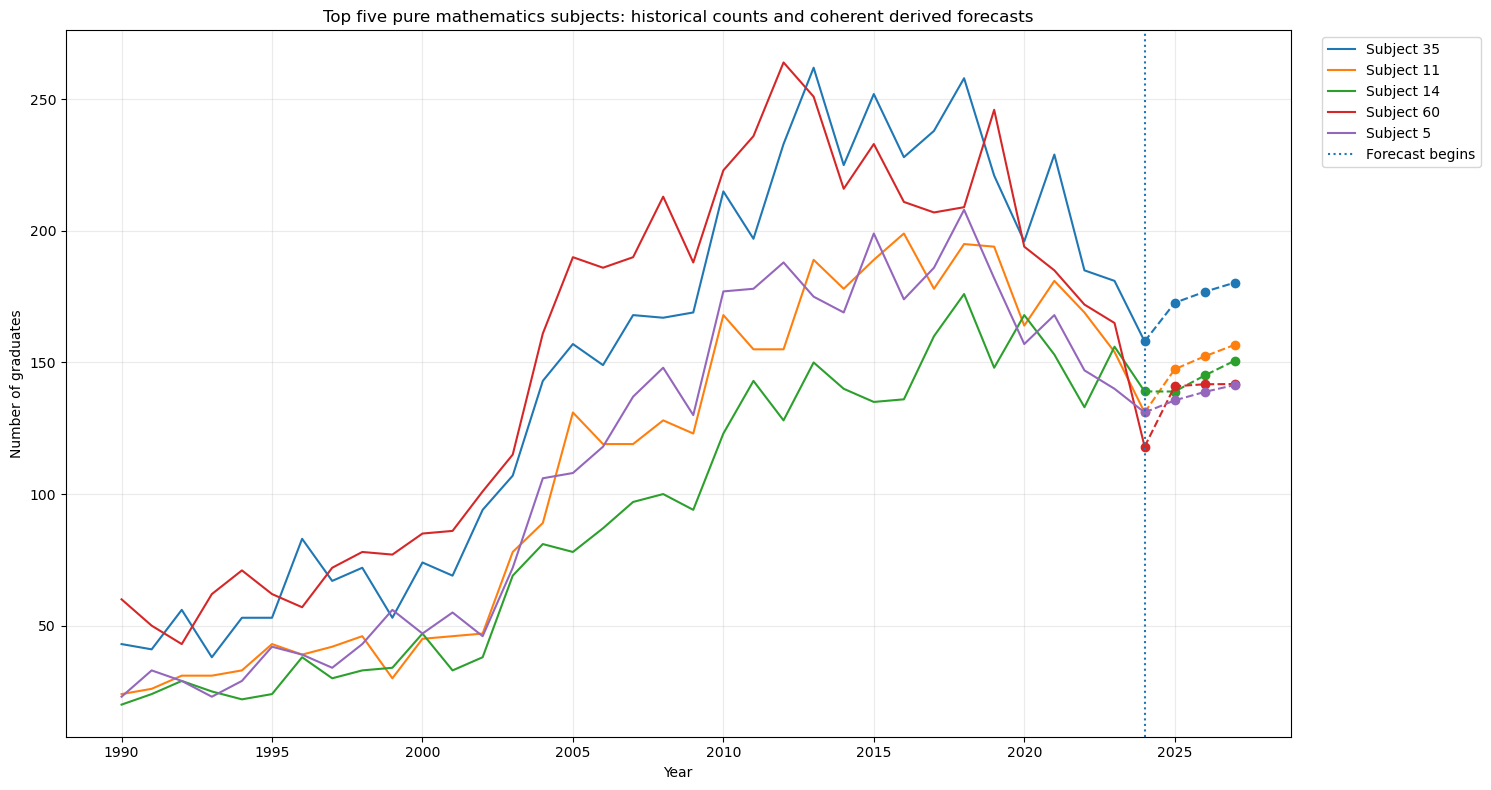

In [112]:
pure_top5_counts, pure_top5_counts_table = (
    select_top_subjects(
        forecast_matrix=pure_counts_forecast,
        top_n=5,
        ranking_method="mean"
    )
)

display(pure_top5_counts_table)

plot_top_subject_forecasts(
    historical_matrix=counts_pure,
    forecast_matrix=pure_counts_forecast,
    top_subject_codes=pure_top5_counts,
    title=(
        "Top five pure mathematics subjects: "
        "historical counts and coherent derived forecasts"
    ),
    ylabel="Number of graduates",
    historical_start_year=1990
)

### 9.2 Pure mathematics: top five by share

year,rank,2025,2026,2027,average_forecast
subject_code,,,,,
35.0,1,10.544001,10.555032,10.562522,10.553852
11.0,2,9.002466,9.091782,9.178698,9.090982
14.0,3,8.485176,8.657611,8.827325,8.656704
60.0,4,8.607685,8.456914,8.305074,8.456558
5.0,5,8.280405,8.283889,8.285087,8.283127


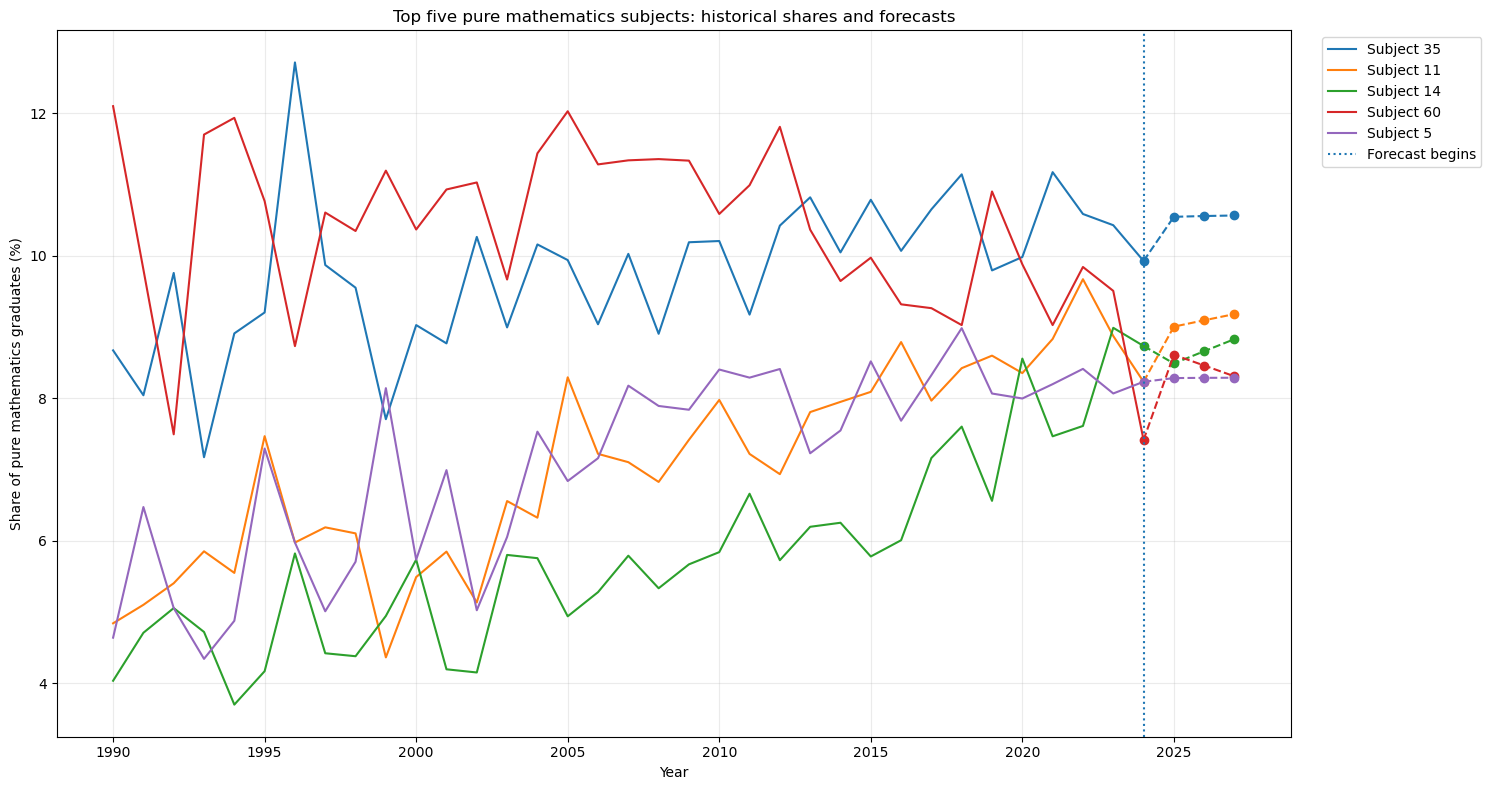

In [113]:
pure_top5_share, pure_top5_share_table = (
    select_top_subjects(
        forecast_matrix=pure_share_forecast,
        top_n=5,
        ranking_method="mean"
    )
)

display(pure_top5_share_table)

pure_share_ylabel = (
    "Share of pure mathematics graduates (%)"
    if share_pure.sum(axis=0).median() > 2
    else "Share of pure mathematics graduates"
)

plot_top_subject_forecasts(
    historical_matrix=share_pure,
    forecast_matrix=pure_share_forecast,
    top_subject_codes=pure_top5_share,
    title=(
        "Top five pure mathematics subjects: "
        "historical shares and forecasts"
    ),
    ylabel=pure_share_ylabel,
    historical_start_year=1990
)

### 9.3 Applied mathematics: top five by derived counts

year,rank,2025,2026,2027,average_forecast
subject_code,,,,,
68.0,1,495.470281,495.470281,495.470281,495.470281
62.0,2,334.041241,334.041241,334.041241,334.041241
65.0,3,152.734070,152.734070,152.734070,152.734070
90.0,4,96.209913,96.209913,96.209913,96.209913
91.0,5,82.226912,82.226912,82.226912,82.226912


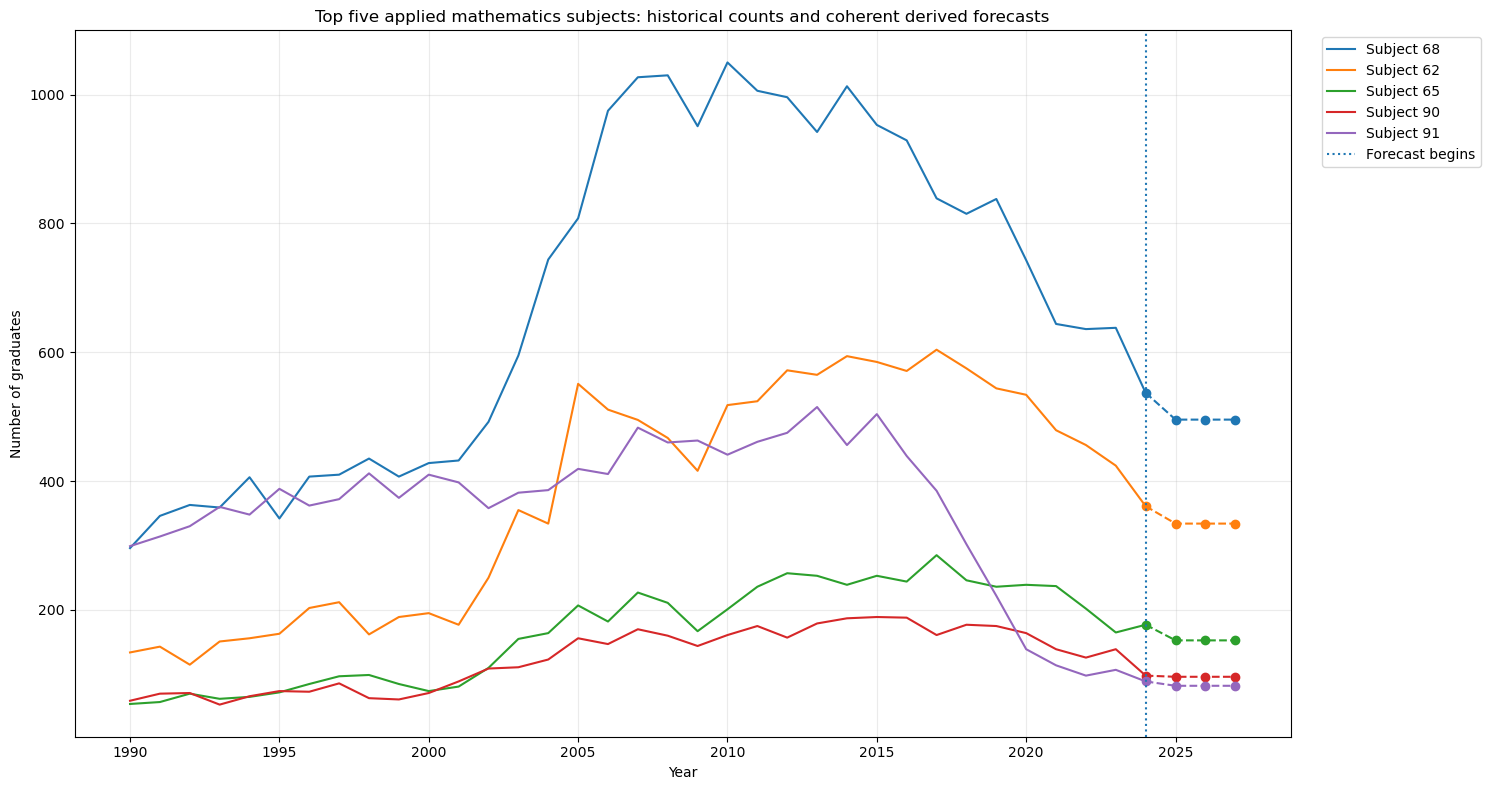

In [117]:
applied_top5_counts, applied_top5_counts_table = (
    select_top_subjects(
        forecast_matrix=applied_counts_forecast,
        top_n=5,
        ranking_method="mean"
    )
)

display(applied_top5_counts_table)

plot_top_subject_forecasts(
    historical_matrix=counts_applied,
    forecast_matrix=applied_counts_forecast,
    top_subject_codes=applied_top5_counts,
    title=(
        "Top five applied mathematics subjects: "
        "historical counts and coherent derived forecasts"
    ),
    ylabel="Number of graduates",
    historical_start_year=1990
)

### 9.4 Applied mathematics: top five by share

year,rank,2025,2026,2027,average_forecast
subject_code,,,,,
68.0,1,32.279463,32.279463,32.279463,32.279463
62.0,2,21.762500,21.762500,21.762500,21.762500
65.0,3,9.950493,9.950493,9.950493,9.950493
90.0,4,6.267993,6.267993,6.267993,6.267993
91.0,5,5.357013,5.357013,5.357013,5.357013


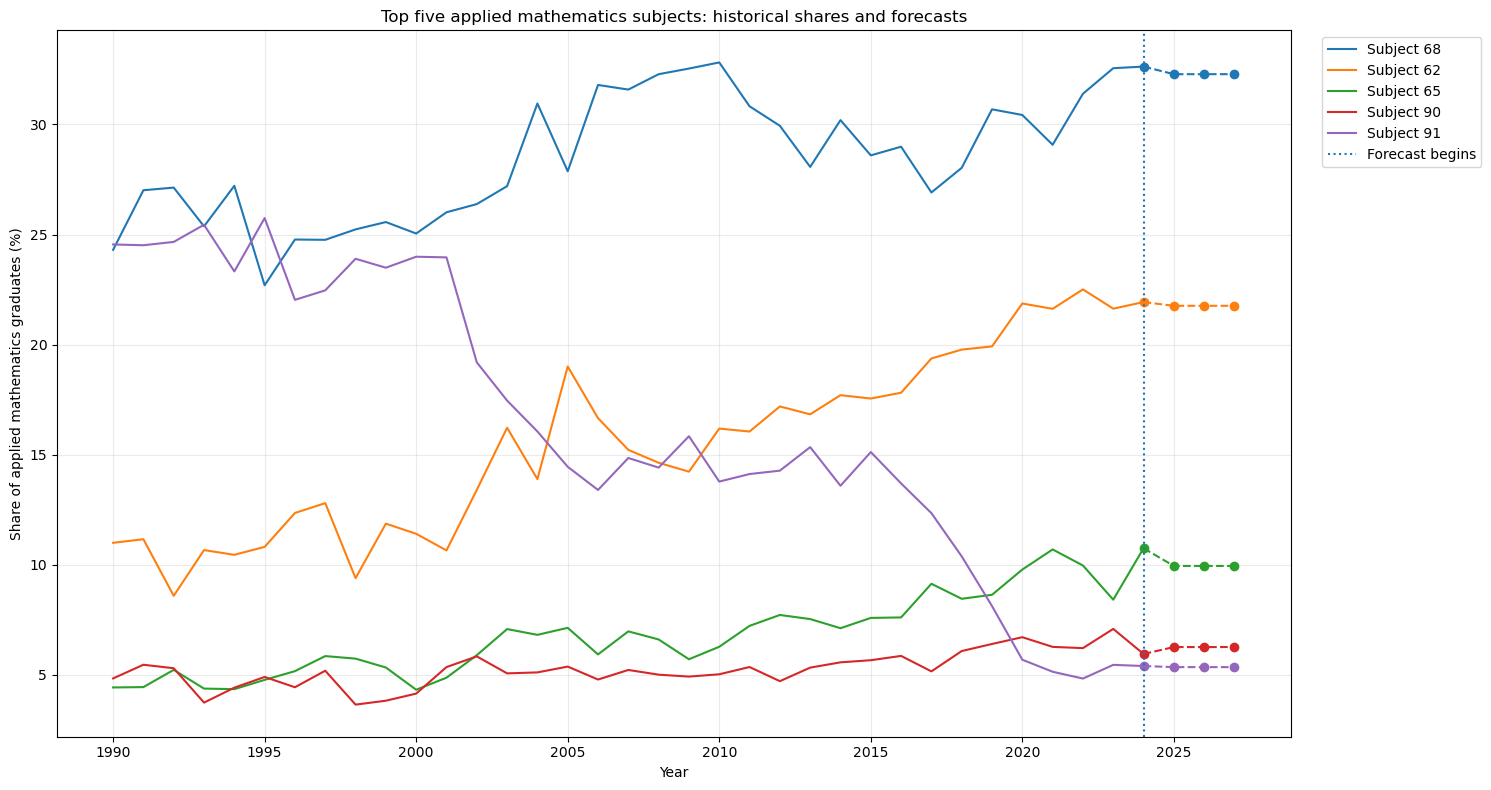

In [118]:
applied_top5_share, applied_top5_share_table = (
    select_top_subjects(
        forecast_matrix=applied_share_forecast,
        top_n=5,
        ranking_method="mean"
    )
)

display(applied_top5_share_table)

applied_share_ylabel = (
    "Share of applied mathematics graduates (%)"
    if share_applied.sum(axis=0).median() > 2
    else "Share of applied mathematics graduates"
)

plot_top_subject_forecasts(
    historical_matrix=share_applied,
    forecast_matrix=applied_share_forecast,
    top_subject_codes=applied_top5_share,
    title=(
        "Top five applied mathematics subjects: "
        "historical shares and forecasts"
    ),
    ylabel=applied_share_ylabel,
    historical_start_year=1990
)